# IMPORT

In [279]:
import pandas as pd
import numpy as np
from numpy import int64
import scipy.stats as stats
import seaborn as sns
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
import os
import sys
# Lấy thư mục hiện hành của Jupyter Notebook
current_dir = os.getcwd()
# Lên 3 cấp để chỉ định thư mục gốc của dự án (chứa thư mục 'src')
project_root = os.path.abspath(os.path.join(current_dir, '..', '..', '..'))
# Thêm thư mục project_root vào sys.path để có thể Import các module từ src
if project_root not in sys.path:
    sys.path.append(project_root)
# Import data_loader (Tệp thư viện nằm tại src/services/data_loader.py)
from src.services import data_loader
from src.core import math_engines


#LOAD DATA

In [280]:
nlg = data_loader.load_stocks(['ACB'])
nlg = pd.DataFrame(nlg['ACB'])
nlg.time = pd.to_datetime(nlg.time)
nlg.set_index('time', inplace=True)
nlg

Bắt đầu đọc 1 file song song...


,open,high,low,close,volume
time,,,,,
2023-09-11 09:15:00,16.00,16.04,16.00,16.04,65100
2023-09-11 09:16:00,16.07,16.07,16.00,16.04,59300
2023-09-11 09:17:00,16.04,16.07,16.04,16.07,11800
2023-09-11 09:18:00,16.04,16.04,16.00,16.04,26500
2023-09-11 09:19:00,16.04,16.04,16.00,16.04,20100
...,...,...,...,...,...
2026-02-27 14:26:00,24.55,24.60,24.50,24.55,150400
2026-02-27 14:27:00,24.55,24.60,24.50,24.55,862900
2026-02-27 14:28:00,24.60,24.60,24.55,24.55,68500


<Axes: xlabel='time'>

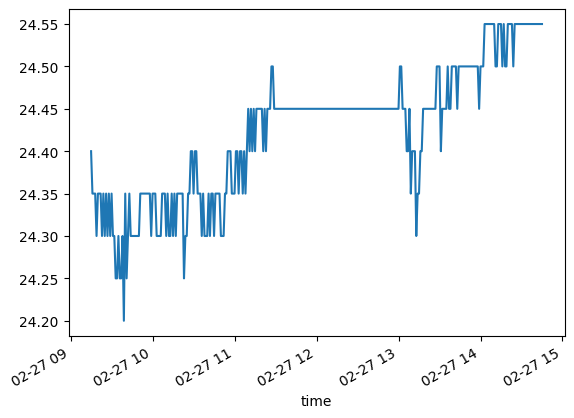

In [281]:
nlg_t = nlg[nlg.index.date == datetime(2026, 2, 27).date()]
nlg_t['close'].plot()

# TIME_BAR

<Axes: >

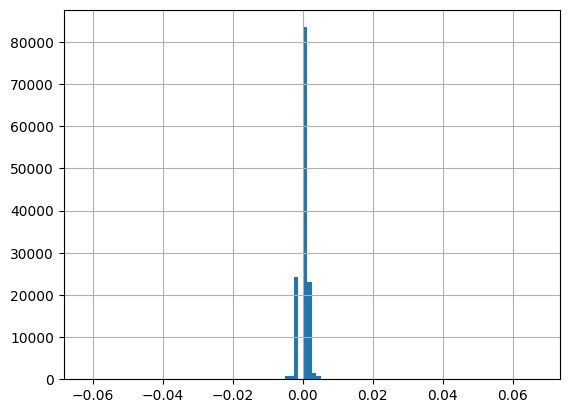

In [282]:
time_bar_return = np.log(nlg.close/nlg.close.shift(1))
time_bar_return.dropna(inplace=True)
time_bar_return.hist(bins=100)

# VOLUME_BAR

# DOLA_BAR

## standard dola bar

In [283]:
nlg['typical_price'] = (nlg.open+nlg.high+nlg.low+nlg.close)/4
nlg['dola_value'] = nlg.typical_price*nlg.volume
nlg.head(10)

,open,high,low,close,volume,typical_price,dola_value
time,,,,,,,
2023-09-11 09:15:00,16.00,16.04,16.00,16.04,65100,16.020,1042902.0
2023-09-11 09:16:00,16.07,16.07,16.00,16.04,59300,16.045,951468.5
2023-09-11 09:17:00,16.04,16.07,16.04,16.07,11800,16.055,189449.0
2023-09-11 09:18:00,16.04,16.04,16.00,16.04,26500,16.030,424795.0
2023-09-11 09:19:00,16.04,16.04,16.00,16.04,20100,16.030,322203.0
2023-09-11 09:20:00,16.04,16.04,16.00,16.00,21300,16.020,341226.0
2023-09-11 09:21:00,16.00,16.04,16.00,16.00,69100,16.010,1106291.0
2023-09-11 09:22:00,16.00,16.00,15.97,15.97,15600,15.985,249366.0
2023-09-11 09:23:00,15.97,15.97,15.97,15.97,3000,15.970,47910.0


In [284]:
def generate_dynamic_dollar_bars_fixed(df, rolling_window=20, n_target=5):
    """
    Động cơ sinh Thanh Đô la (Dollar Bars) với ngưỡng Vt cập nhật động (Rolling).
    
    Yêu cầu đầu vào:
    - df: DataFrame với DatetimeIndex. Các cột: 'price', 'volume', 'dola_value'.
    """
    print("1. Bắt đầu tiền xử lý: Tính toán Bảng tra cứu Vt (Rolling Window)...")

    # Tính Tổng Đô la hàng ngày và lọc ngày nghỉ
    daily_dollar_volume = df['dola_value'].resample('D').sum()
    daily_dollar_volume = daily_dollar_volume[daily_dollar_volume > 0] 

    # Giải quyết Điểm nghẽn 1: Ảo tưởng Cửa sổ trượt & Rò rỉ Dữ liệu
    # Dùng hàm rolling chuẩn của Pandas để tạo Cửa sổ trượt liên tục.
    rolling_mean = daily_dollar_volume.rolling(window=rolling_window, min_periods=rolling_window).mean()
    
    # Dịch chuyển (shift) 1 bước: Lấy kết quả của ngày T-1 để áp dụng làm ngưỡng Vt cho ngày T.
    daily_vt = (rolling_mean / n_target).shift(1)
    
    # Chuyển thành Dictionary để tra cứu với độ phức tạp thời gian O(1)
    vt_dict = daily_vt.dropna().to_dict()

    print("2. Hoàn tất Bảng tra cứu. Bắt đầu lấy mẫu Dollar Bars...")

    # Khởi tạo các biến Trạng thái
    bars = []
    cum_dollar = 0.0
    cum_volume = 0.0
    cum_ticks = 0
    high_price = -np.inf
    low_price = np.inf
    open_price = None
    open_time = None

    # Vòng lặp lấy mẫu
    for row in df.itertuples():
        current_datetime = row.Index
        current_date = current_datetime.date()
        
        # Tra cứu Vt của ngày hiện tại
        current_vt = vt_dict.get(current_date, np.nan)
        
        # Pruning: Bỏ qua các ngày đầu tiên chưa đủ dữ liệu để tạo cửa sổ trượt
        if pd.isna(current_vt):
            continue
            

        price = row.typical_price
        volume = row.volume
        dollar_val = row.dola_value
        
        # Khởi tạo thanh mới
        if open_price is None:
            open_price = price
            open_time = current_datetime
            
        # Tích lũy các biến số
        cum_dollar += dollar_val
        cum_volume += volume
        cum_ticks += 1
        if price > high_price: high_price = price
        if price < low_price: low_price = price
            
        # Giải quyết Điểm nghẽn 2 & 3: Kiểm tra Ngưỡng và Hấp thụ Phần dư
        if cum_dollar >= current_vt:
            bars.append({
                'open_time': open_time,
                'close_time': current_datetime,
                'open': open_price,
                'high': high_price,
                'low': low_price,
                'close': price,
                'volume': cum_volume,        # Ghi nhận TỔNG khối lượng thực tế (Bao gồm Overshoot)
                'dola_value': cum_dollar,    # Ghi nhận TỔNG Đô la thực tế (Sẽ lớn hơn hoặc bằng Vt)
                'tick_count': cum_ticks,
                'vt_threshold': current_vt
            })
            
            # Hard Reset: Thiết lập lại toàn bộ cấu trúc vi mô về 0 cho thanh tiếp theo.
            # Không bảo lưu "Tiền ma" (Ghost Dollars) sang chu kỳ sau.
            cum_dollar = 0.0
            cum_volume = 0.0
            cum_ticks = 0
            high_price = -np.inf
            low_price = np.inf
            open_price = None 

    # Đóng gói dữ liệu đầu ra
    dollar_bars_df = pd.DataFrame(bars)
    if not dollar_bars_df.empty:
        dollar_bars_df.set_index('close_time', inplace=True)
        
    return dollar_bars_df

In [285]:
def generate_dynamic_dollar_bars(df, rolling_window=20, n_target=20):
    """
    Động cơ sinh Thanh Đô la (Dollar Bars) với ngưỡng Vt cập nhật động qua từng ngày.
    Đã điều chỉnh logic OHLC và Cache Reset để mô phỏng HOÀN TOÀN CHÍNH XÁC MLFinLab.
    """
    print("Bắt đầu tiền xử lý: Tính toán Bảng tra cứu Vt...")
    
    # 1. Tạo chuỗi Tổng Đô la hàng ngày
    daily_dollar_volume = df['dola_value'].resample('D').sum()
    daily_dollar_volume = daily_dollar_volume[daily_dollar_volume > 0] # Lọc ngày nghỉ
    
    # 2. Xây dựng Từ điển Tra cứu Vt (Kiểu Nhảy Bậc - Stepped Window)
    vt_dict = {}
    unique_dates = np.unique(df.index.date)
    
    # Duyệt qua các ngày theo từng bước nhảy (step) bằng đúng rolling_window
    for i in range(0, len(unique_dates), rolling_window):
        current_block = unique_dates[i : i + rolling_window]
        next_block = unique_dates[i + rolling_window : i + 2 * rolling_window]
        
        is_in_block = np.isin(daily_dollar_volume.index.date, current_block)
        block_data = daily_dollar_volume[is_in_block]
        
        if len(block_data) >= rolling_window:
            calculated_vt = block_data.mean() / n_target
        else:
            calculated_vt = np.nan 
            
        for d in next_block:
            vt_dict[d] = calculated_vt
            
        if i == 0:
            for d in current_block:
                if d not in vt_dict: vt_dict[d] = np.nan

    print("Hoàn tất Bảng tra cứu. Bắt đầu lấy mẫu Dollar Bars lấy chuẩn chuẩn OHLC của MLFinlab...")
    
    # 3. Khởi tạo các biến Trạng thái State Variable
    bars = []
    cum_dollar = 0.0
    cum_volume = 0.0
    cum_ticks = 0
    high_price = -np.inf
    low_price = np.inf
    open_price = None
    open_time = None

    # Lặp qua từng dòng dữ liệu định tuyến
    for row in df.itertuples():
        current_datetime = row.Index
        current_date = current_datetime.date()
        
        current_vt = vt_dict.get(current_date, np.nan)
        
        if pd.isna(current_vt):
            continue
            
        curr_open = row.open
        curr_high = row.high
        curr_low = row.low
        curr_close = row.close
        
        volume = row.volume
        dollar_val = row.dola_value
        
        # O: Giá Mở cửa là giá Open của phút ĐẦU TIÊN
        if open_price is None:
            open_price = curr_open
            open_time = current_datetime
            
        # Cập nhật cache (Tích lũy)
        cum_dollar += dollar_val
        cum_volume += volume
        cum_ticks += 1
        
        # H & L: High và Low đo theo độ phân tán rộng nhất (Râu nến)
        # MLFinlab cũng so sánh thêm với cả open price
        if curr_high > high_price: high_price = curr_high
        if curr_low < low_price: low_price = curr_low
        high_price_bar = max(high_price, open_price)
        low_price_bar = min(low_price, open_price)
            
        # 4. KIỂM TRA NGƯỠNG (THRESHOLD)
        if cum_dollar >= current_vt:
            # Tạo lập Bar giống StandardBars._create_bars của MLFinLab
            bars.append({
                'open_time': open_time,
                'close_time': current_datetime, 
                'open': open_price,              
                'high': high_price_bar,              
                'low': low_price_bar,                
                'close': curr_close,             
                'volume': cum_volume,
                'dola_value': cum_dollar,        
                'tick_count': cum_ticks,
                'vt_threshold': current_vt 
            })
            
            # Reset cache hoàn toàn giống StandardBars._reset_cache của MLFinLab
            # Tuyệt đối không giữ lại hay cấn trừ (carry-over) bất kì giá trị nào
            cum_dollar = 0.0
            cum_volume = 0.0
            cum_ticks = 0
            high_price = -np.inf
            low_price = np.inf
            open_price = None 
            open_time = None

    dollar_bars_df = pd.DataFrame(bars)
    if not dollar_bars_df.empty:
        dollar_bars_df.set_index('close_time', inplace=True)
        
    return dollar_bars_df


In [286]:
def test_normality(bars_df, title="Dollar Bars Normality Test"):
    """
    Thực hiện kiểm định tính chuẩn toàn diện trên chuỗi Lợi suất Logarit.
    """
    # 1. Tính Log Returns
    # Thay 'close' bằng tên cột giá đóng cửa thực tế trong DataFrame của Anh
    returns = np.log(bars_df['close'] / bars_df['close'].shift(1)).dropna()
    
    # 2. Tính toán các Moment Thống kê
    skewness = stats.skew(returns)
    kurtosis = stats.kurtosis(returns) # Hàm này trả về Excess Kurtosis (Độ nhọn vượt trội so với phân phối chuẩn có mức = 0)
    
    # 3. Kiểm định Jarque-Bera
    jb_stat, p_value = stats.jarque_bera(returns)
    
    # 4. In Báo cáo
    print(f"--- BÁO CÁO THỐNG KÊ: {title} ---")
    print(f"Số lượng quan sát (N): {len(returns)}")
    print(f"Độ lệch (Skewness)  : {skewness:.4f} (Gần 0 là tốt)")
    print(f"Độ nhọn (Kurtosis)   : {kurtosis:.4f} (Gần 0 là tốt. >0 là đuôi béo)")
    print(f"Jarque-Bera Stat     : {jb_stat:.2f}")
    print(f"P-value              : {p_value:.6e}")
    
    # 5. Vẽ đồ thị Trực quan hóa
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Đồ thị Histogram & KDE so với Phân phối chuẩn
    sns.histplot(returns, kde=True, stat='density', ax=axes[0], color='blue', bins=100)
    xmin, xmax = axes[0].get_xlim()
    x = np.linspace(xmin, xmax, 100)
    p = stats.norm.pdf(x, np.mean(returns), np.std(returns))
    axes[0].plot(x, p, 'k', linewidth=2, label='Normal Curve')
    axes[0].set_title('Histogram & KDE')
    axes[0].legend()
    
    # Biểu đồ Q-Q Plot
    stats.probplot(returns, dist="norm", plot=axes[1])
    axes[1].set_title('Q-Q Plot')
    
    plt.tight_layout()
    plt.show()

Bắt đầu tiền xử lý: Tính toán Bảng tra cứu Vt...
Hoàn tất Bảng tra cứu. Bắt đầu lấy mẫu Dollar Bars lấy chuẩn chuẩn OHLC của MLFinlab...
--- BÁO CÁO THỐNG KÊ: Dollar Bars ---
Số lượng quan sát (N): 3113
Độ lệch (Skewness)  : 1.9998 (Gần 0 là tốt)
Độ nhọn (Kurtosis)   : 46.0190 (Gần 0 là tốt. >0 là đuôi béo)
Jarque-Bera Stat     : 276764.09
P-value              : 0.000000e+00


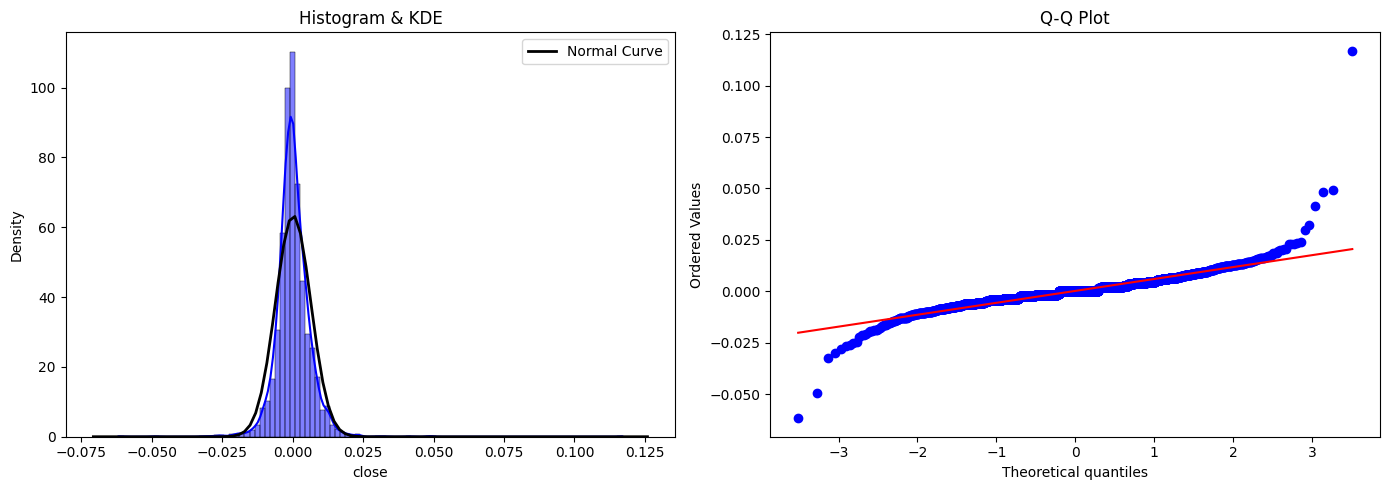

In [287]:
df = generate_dynamic_dollar_bars(nlg, rolling_window=20, n_target=5)
# df = df[df.index.date >= df.index.date.max() - timedelta(1000)]
# print(df.tail(10))
test_normality(df, "Dollar Bars")

In [288]:
def generate_time_bars_real(df, expected_bars=3078):
    """
    Động cơ sinh Thanh Thời gian (Time Bars) tương đương về tần suất.
    """
    # 1. Tính toán Tổng thời gian vật lý của chuỗi dữ liệu
    time_span = df.index[-1] - df.index[0]
    
    # 2. Tính Tần suất Lấy mẫu Trung bình (T) bằng Giây
    freq_seconds = int(time_span.total_seconds() / expected_bars)
    freq_str = f"{freq_seconds}s" # Định dạng chuẩn của Pandas (ví dụ: '300S' = 5 phút)
    
    print(f"[Time Bars] Khoảng thời gian mỗi thanh (T): {freq_seconds} giây ({freq_seconds/60:.2f} phút)")
    
    # 3. Resample theo Thời gian thực
    time_bars = df.resample(freq_str).agg(
        open=('typical_price', 'first'),
        high=('typical_price', 'max'),
        low=('typical_price', 'min'),
        close=('typical_price', 'last'),
        volume=('volume', 'sum'),
        dola_value=('dola_value', 'sum')
    )
    
    # 4. Loại bỏ các khoảng thời gian "chết" (Thị trường không có giao dịch)
    time_bars = time_bars.dropna()
    time_bars.index.name = 'close_time'
    
    print(f"[Time Bars] Số thanh thực tế tạo ra (sau khi bỏ thanh rỗng): {len(time_bars)}")
    return time_bars

[Time Bars] Khoảng thời gian mỗi thanh (T): 4500 giây (75.00 phút)
[Time Bars] Số thanh thực tế tạo ra (sau khi bỏ thanh rỗng): 442
                        open    high      low    close   volume    dola_value
close_time                                                                   
2026-02-27 08:45:00  24.4250  24.425  24.2375  24.3250  1864900  4.535443e+07
2026-02-27 10:00:00  24.3250  24.450  24.2750  24.4375  1634200  3.978228e+07
2026-02-27 11:15:00  24.4125  24.500  24.4125  24.4500   779800  1.904925e+07
2026-02-27 12:30:00  24.4625  24.500  24.3375  24.4875  2091100  5.110919e+07
2026-02-27 13:45:00  24.5000  24.575  24.4750  24.5500  4679000  1.148172e+08
--- BÁO CÁO THỐNG KÊ: Dollar Bars Normality Test ---
Số lượng quan sát (N): 441
Độ lệch (Skewness)  : 0.4396 (Gần 0 là tốt)
Độ nhọn (Kurtosis)   : 5.4728 (Gần 0 là tốt. >0 là đuôi béo)
Jarque-Bera Stat     : 564.55
P-value              : 2.561601e-123


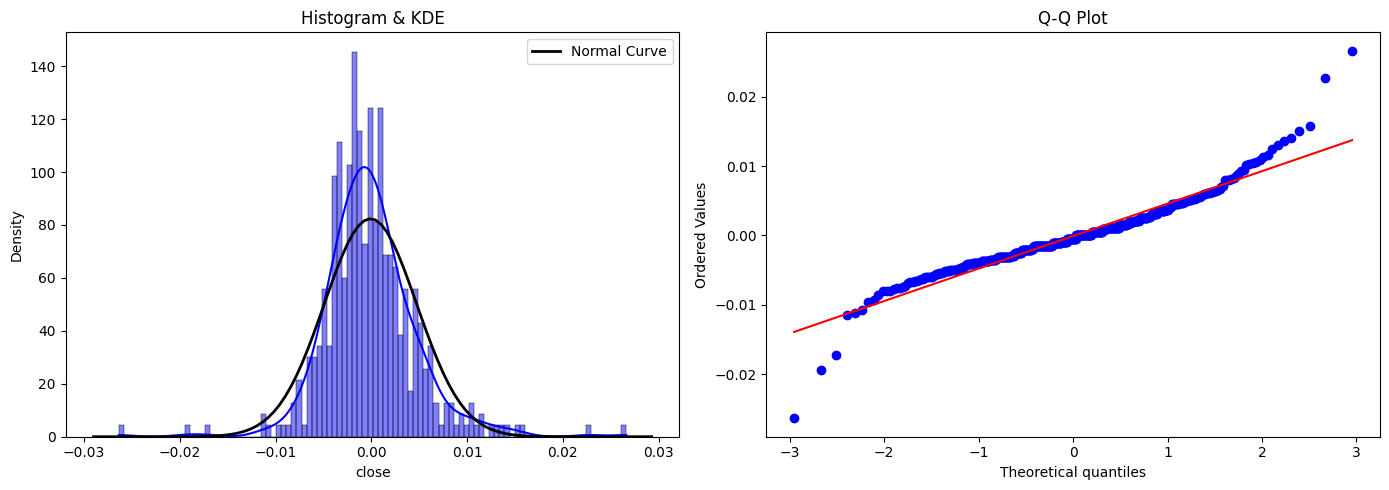

In [289]:
# Chạy thực thi
nlg = nlg[nlg.index.date >= nlg.index.date.max() - timedelta(130)]
df_time_bars = generate_time_bars_real(nlg, expected_bars=2500)
print(df_time_bars.tail())
test_normality(df_time_bars)